In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers

In [2]:
#call functions
params = bacteriaSys.default_params_2()
Ad1, Bd1 = bacteriaSys.discretize_AB(0.7, 0.03, 1.0)
print("Discretized A matrix:\n", Ad1)
print("Discretized B matrix:\n", Bd1)
Ad2, Bd2 = bacteriaSys.discretize_AB(0.6, 0.04, 1.0)
C = np.array([[0, 1]])
D = np.array([[0]])
num1, den1 = gapMetrics.ss_to_tf_discrete(Ad1, Bd1, C, D)
num2, den2 = gapMetrics.ss_to_tf_discrete(Ad2, Bd2, C, D)
v_gap = gapMetrics.vgap_metric(num1, den1, num2, den2)
print("v-gap between the two systems:", v_gap)
#For proportional controller with gain K
K = 1.0
num3 = np.empty((1, 1), dtype=object)
den3 = np.empty((1, 1), dtype=object)
num3[0, 0] = np.array([K])
den3[0, 0] = np.array([1.0])

bpc, _, _ = gapMetrics.vgap_bpc(num1, den1, num3, den3)
print("bpc:", bpc)

#simulate system to get data
u = gapMetrics.persistently_exciting_input(50)
x,y = gapMetrics.simulate_system(Ad1, Bd1, C, D, u)

A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
print("Estimated A matrix:\n", A_hat)
print("Estimated B matrix:\n", B_hat)

Discretized A matrix:
 [[0.4965853  0.        ]
 [0.70725407 0.97044553]]
Discretized B matrix:
 [[0.71916385]
 [0.39699258]]
v-gap between the two systems: (0.04390122146430629, np.float64(0.04390122146430629))
bpc: 0.692104946462384
Estimated A matrix:
 [[4.96585304e-01 1.32581828e-16]
 [7.07254074e-01 9.70445534e-01]]
Estimated B matrix:
 [[0.71916385]
 [0.39699258]]


In [31]:
#generate 50 random systems
num_systems = 50
T = 50 #number of data points each system
L = 15  #Hankel matrix depth
C = np.array([[0.5, 1]])
D = np.array([[0]])
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
stored_hankels = []
H_u = gapMetrics.hankel_matrix(u, L)
#store x for LQR related
stored_x = []
#store A and B for checking
stored_A = []
stored_B = []
for i in range(num_systems):
    random_params_1 = random.random()
    random_params_2 = random.random()
    A, B =bacteriaSys.discretize_AB(random_params_1, random_params_2, 1.0)
    x, y = gapMetrics.simulate_system(A, B, C, D, u)
    H_y = gapMetrics.hankel_matrix(y, L)
    H = np.vstack([H_u, H_y])
    stored_x.append(x)
    stored_hankels.append(H)
    stored_A.append(A)
    stored_B.append(B)

In [15]:
#compute L gaps
m = 1      # number of inputs
n = 2      # state dimension
D = np.zeros((num_systems, num_systems))
for i in range(num_systems):
    for j in range(i+1, num_systems):
        gij, *_ = gapMetrics.Lgap_metric(stored_hankels[i], stored_hankels[j], m, n, L, use_alt_formula=False)
        D[i, j] = gij
        D[j, i] = gij

# plt.figure()
# plt.imshow(D, interpolation="nearest", aspect="auto")
# plt.colorbar(label="L-gap")
# plt.title("Pairwise L-gap matrix")
# plt.xlabel("System index")
# plt.ylabel("System index")
# plt.show()

print("D:", D)


D: [[0.         0.23352692 0.06188416 ... 0.2166655  0.42573329 0.1308295 ]
 [0.23352692 0.         0.27959963 ... 0.10173854 0.20520016 0.15123028]
 [0.06188416 0.27959963 0.         ... 0.25941546 0.46823093 0.19066545]
 ...
 [0.2166655  0.10173854 0.25941546 ... 0.         0.27768534 0.1338691 ]
 [0.42573329 0.20520016 0.46823093 ... 0.27768534 0.         0.33868168]
 [0.1308295  0.15123028 0.19066545 ... 0.1338691  0.33868168 0.        ]]


In [27]:
def leader_groups(D, threshold):
    """
    Star clustering: each group has a leader c, and all members i satisfy D[i,c] <= threshold.
    Greedy: choose leader that covers the most uncovered nodes.
    Returns list of dicts: [{"leader": c, "members": [...]}]
    """
    N = D.shape[0]
    uncovered = set(range(N))
    groups = []

    # Precompute who is within threshold of whom (including self)
    within = [set(np.where(D[i] <= threshold)[0].tolist()) for i in range(N)]

    while uncovered:
        # choose leader that covers most uncovered nodes
        best_leader = None
        best_cover = set()
        for i in uncovered:
            cover = within[i] & uncovered
            if len(cover) > len(best_cover):
                best_cover = cover
                best_leader = i

        members = sorted(best_cover)
        groups.append({"leader": int(best_leader), "members": [int(x) for x in members]})

        # mark them covered
        for x in best_cover:
            uncovered.remove(x)

    return groups


In [28]:
eps = 0.2
groups = leader_groups(D, eps)
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groups:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D[leader, i]




leader: 45 size: 37 members: [0, 1, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 18, 22, 23, 25, 26, 27, 29, 30, 31, 32, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 49]
leader: 7 size: 9 members: [7, 17, 19, 20, 24, 28, 34, 43, 48]
leader: 2 size: 4 members: [2, 8, 21, 33]


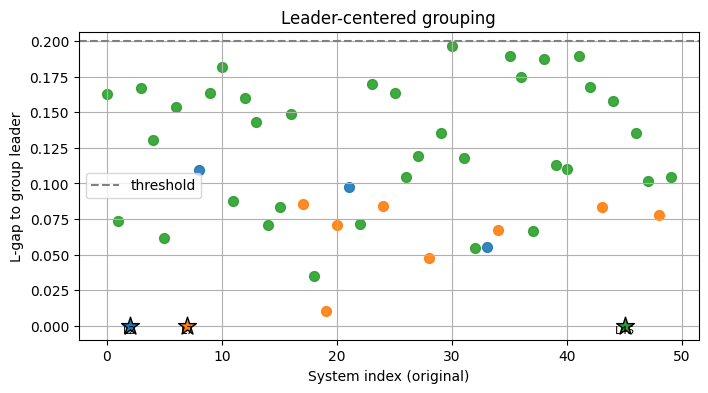

In [29]:
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab10(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

plt.axhline(eps, linestyle="--", color="gray", label="threshold")
plt.xlabel("System index (original)")
plt.ylabel("L-gap to group leader")
plt.title("Leader-centered grouping")
plt.grid(True)
plt.legend()
plt.show()


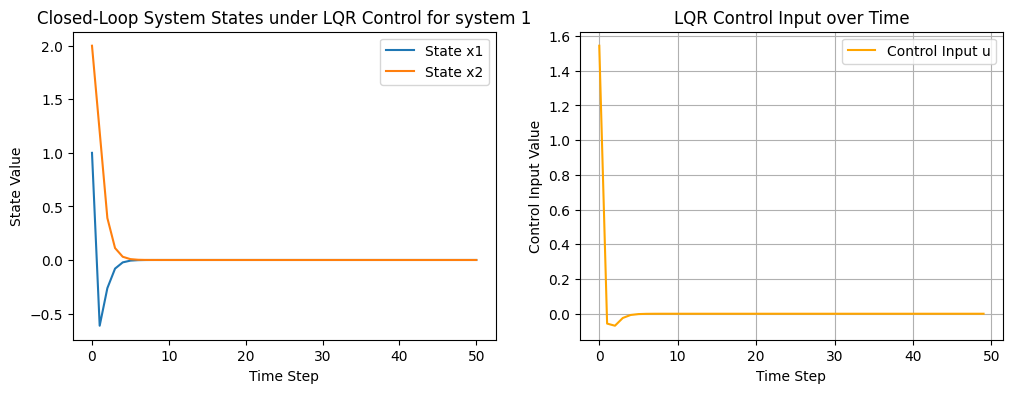

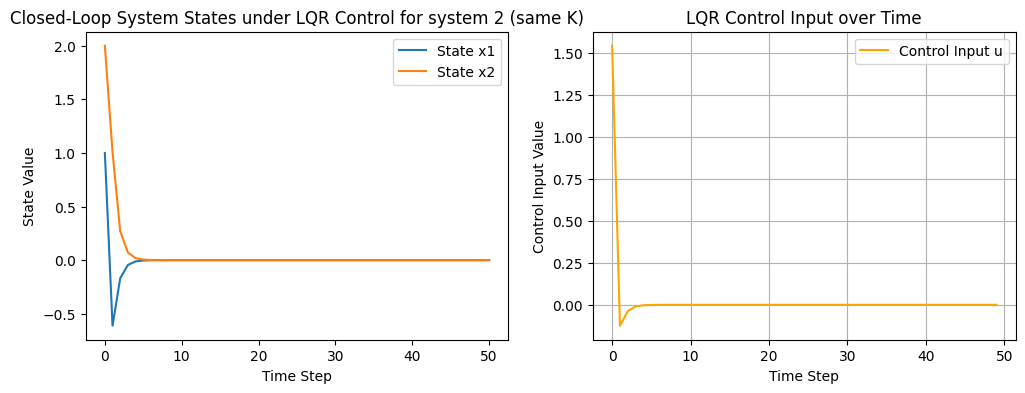

In [32]:
#proof of controllability

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)*0.1
T_d = 20  #data length for LQR

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[45][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[45][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 50 #number of control steps
x0 = np.array([[1],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[0],[0]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[45] @ x_cl[k] + stored_B[45] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[30] @ x_cl[k] + stored_B[30] @ u_control
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()